############# Оптимизация управление персоналом «Работа с заботой»

Перечень функций:

In [1]:
def edit_names_columns(df):
    
    """Переводит имена столбцов в нижний регистр, удаляет пробелы в начале и конце имени, 
    заменяет пробелы на знак нижнего подчеркивания"""
    
    df.columns = [x.lower().strip().replace(' ', '_') for x in df.columns]
    print(df.columns)

In [2]:
def primary_info(df):
    
    '''Расчитывает количество дубликатов и пропусков в данных, 
    выводит информацию о количественных и категориальных данных'''
    
    data = df.drop('id', axis=1)
    print(f'Количество пропусков:\n{df.isna().sum()}\n')
    print(f'Количество дубликатов: {df.duplicated().sum()}\n')
    print(f'Количественные признаки: {data.select_dtypes(include=[np.number]).columns.tolist()}\n')
    print(f'Категориальные признаки: {data.select_dtypes(exclude=[np.number]).columns.tolist()}\n')

In [3]:
def plot_num_columns(df):
    
    """Строит гистрограмму и ящик с усами по количественным признакам."""
    
    names_num_columns = df.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
    for name_column in names_num_columns:
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Распределение признака {name_column}', fontsize=16)
        
        sns.histplot(data=df, x=name_column, ax=ax1)
        ax1.set_title(f'Гистограмма признака {name_column}')
        ax1.set_ylabel('Количество')
        
        sns.boxplot(data=df, x=name_column, ax=ax2)
        ax2.set_title(f'Ящик с усами признака {name_column}')
        
        plt.show()

In [4]:
def plot_cat_columns(df):
    
    """Строит графики countplot по категориальным признакам."""
    
    names_cat_columns = df.select_dtypes(exclude = [np.number]).columns.tolist()
    
    while len(names_cat_columns) > 0:
        plt.figure(figsize=(15, 5))
        for i in [1, 2]:
            if len(names_cat_columns) > 0:
                name_column = names_cat_columns.pop(0)
                plt.subplot(1, 2, i)
                sns.countplot(data=df, x=name_column, orient='h')
                plt.title(f'Распределение признака {name_column}')
                plt.ylabel('Количество')
                locs, labels = plt.xticks()
                plt.setp(labels, rotation=60)
            else:
                continue
        plt.show

In [5]:
def regression_metrics(model, X_test, y_test):
    """Рассчитывает метрики MAE, MSE и строит графику предсказаний."""
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    plt.scatter(y_test, y_pred)
    plt.title('График предсказаний')
    plt.xlabel('Фактические значения')
    plt.ylabel('Предсказанные значения')
    plt.show()
    
    print(f'MAE: {mae:.3f}')
    print(f'MSE: {mse:.3f}')


In [6]:
# создаём функцию для расчёта точности предсказаний каждого класса

def custom_metric(y_true, y_pred):
    """
    Рассчитывает значение метрики SMAPE (симметричная средняя абсолютная процентная ошибка).
    
    Аргументы:
    y_true: массив NumPy или объект Series в pandas, содержащий истинные значения
    y_pred: массив NumPy или объект Series в pandas, содержащий предсказанные значения
    
    Возвращает:
    float: значение метрики SMAPE
    """
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    smape = np.mean(numerator / denominator) * 100

    return smape

In [7]:
!pip install scikit-learn==1.1.3 -q

   HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.
   
   Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
   Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 
   
  У нас будет несколько задач. 
  Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
  Ваша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

######## Цель проекта: 1. написать мо для предсказания уровня удовлетворенности сотрудника
                       2. построить мо для предсказания увольнения сотрудника    

  ####### План проекта: 

 Задача 1: предсказание уровня удовлетворённости сотрудника

 Для этой задачи заказчик предоставил данные с признаками:
 id — уникальный идентификатор сотрудника;
 dept — отдел, в котором работает сотрудник;
 level — уровень занимаемой должности;
 workload — уровень загруженности сотрудника;
 employment_years — длительность работы в компании (в годах);
 last_year_promo — показывает, было ли повышение за последний год;
 last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
 supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
 salary — ежемесячная зарплата сотрудника;
 job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.
 
 Шаг 1. Загрузка данных
  Загрузим файлы с данными:
Тренировочная выборка:
train_job_satisfaction_rate.csv
Входные признаки тестовой выборки:
test_features.csv
Целевой признак тестовой выборки:
test_target_job_satisfaction_rate.csv
  Шаг 2. Предобработка данных
 Изучим данные и сделаем выводы. При необходимости выполним предобработку. Если есть пропуски, заполним их в пайплайне.
  Шаг 3. Исследовательский анализ данных
 Исследуем все признаки и сделаем выводы о том, как их нужно подготовить.
  Шаг 4. Подготовка данных
 Подготовку признаков выполним в пайплайне, дополнив пайплайн шага предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика.
  Шаг 5. Обучение моделей
  Обучим как минимум две модели. Возьмем одну линейную модель, а в качестве второй — дерево решений.     Подберем гиперпараметры как минимум для одной модели с помощью одного из известных нам инструментов.
  Выберем лучшую модель и проверим её качество. Выбор делаем на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»).
  Напишем функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Используем эту метрику при подборе гиперпараметров и оценке качества моделей. 
  Критерий успеха: SMAPE ≤ 15 ≤ 15 на тестовой выборке.
  В решении сохраним работу со всеми моделями, которые мы пробовали. Сделаем выводы.
  Шаг 6. Оформление выводов
 Сделаем промежуточные выводы о том, какая модель справилась лучше и почему.
 
  Задача 2: предсказание увольнения сотрудника из компании
 Для этой задачи мы можем использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.
  Шаг 1. Загрузка данных
Загрузим данные из файлов:
Тренировочная выборка:
train_quit.csv
Входные признаки тестовой выборки те же, что и в прошлой задаче:
test_features.csv
Целевой признак тестовой выборки:
test_target_quit.csv
  Шаг 2. Предобработка данных
Изучим данные и при необходимости выполним предобработку. Если есть пропуски, заполним их в пайплайне.
  Шаг 3. Исследовательский анализ данных
 3.1. Проведем исследовательский анализ данных.
 3.2. Составим портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.
 3.3. Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используем данные с обоими целевыми признаками тестовой выборки.
  Шаг 4. Добавление нового входного признака
 Допустим, job_satisfaction_rate и quit действительно связаны и мы получили необходимое значение метрики в первой задаче. Тогда добавим job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.
  Шаг 5. Подготовка данных
 Подготовим признаки так же, как и в первой задаче: выполним подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика.
  Шаг 6. Обучение модели
 Обучим как минимум три модели. Как минимум для двух из них подберем гиперпараметры. Проверим качество лучшей модели.
 Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC ≥ 0.91 ≥ 0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.
  Шаг 7. Выводы
 Сделаем промежуточные выводы о том, какая модель справилась лучше и почему.
 Общий вывод
 Сформулируем общий вывод:
 опишем задачу;
 опишем все этапы работы;
 добавим выводы и дополнительные предложения для бизнеса.

## Загрузка данных

Шаг 1. Загрузим и изучим данные и необходимые библиотеки

In [8]:
!pip install -U scikit-learn -q
!pip install shap -q

In [9]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install shap -q

Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, recall_score, precision_score, RocCurveDisplay, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
import shap

In [12]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

1.2 Проверим, что данные в таблицах соответствуют описанию. Исследованием и объединением данных займёмся позже.

In [13]:
try:
    df_train_data = pd.read_csv('/datasets/train_job_satisfaction_rate.csv', sep=',', decimal='.')
except:
    df_train_data = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\train_job_satisfaction_rate.csv', sep=',', decimal='.')
    
df_train_data.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [14]:
try:
    df_test_features = pd.read_csv('/datasets/test_features.csv', sep=',', decimal='.')
except:
    df_test_features = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\test_features.csv', sep=',', decimal='.')
    
df_test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [15]:
try:
    df_test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv', sep=',', decimal='.')
except:
    df_test_target = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\test_target_job_satisfaction_rate.csv', sep=',', decimal='.')
    
df_test_target.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [16]:
df_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [17]:
df_test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [18]:
df_test_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Данные в таблице требуют предобработки, требуется проверить явные и не явные дубликаты.  Точно строки между файлами находятся в разном порядке.

##  Предобработка данных

Проведем необходимую предобработку данных.

Файл train_data

In [19]:
# Отредактируем имена столбцов
edit_names_columns(df_train_data)

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'job_satisfaction_rate'],
      dtype='object')


In [20]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_train_data)

Количество пропусков:
id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

Категориальные признаки: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']



In [21]:
# Проверим данные в столбце dept на неявные дубликаты
df_train_data['dept'].sort_values().unique()

array(['hr', 'marketing', 'purchasing', 'sales', 'technology', nan],
      dtype=object)

In [22]:
# Проверим данные в столбце dept на неявные дубликаты
df_train_data['level'].sort_values().unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [23]:
# Проверим данные в столбце dept на неявные дубликаты
df_train_data['workload'].sort_values().unique()

array(['high', 'low', 'medium'], dtype=object)

In [24]:
# Проверим данные в столбце dept на неявные дубликаты
df_train_data['last_year_promo'].sort_values().unique()

array(['no', 'yes'], dtype=object)

In [25]:
# Проверим данные в столбце dept на неявные дубликаты
df_train_data['last_year_violations'].sort_values().unique()

array(['no', 'yes'], dtype=object)

Файл df_test_features

In [26]:
# Отредактируем имена столбцов
edit_names_columns(df_test_features)

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary'],
      dtype='object')


In [27]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_test_features)

Количество пропусков:
id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['employment_years', 'supervisor_evaluation', 'salary']

Категориальные признаки: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']



In [28]:
# Проверим данные в столбце dept на неявные дубликаты
df_test_features['dept'].sort_values().unique()

array([' ', 'hr', 'marketing', 'purchasing', 'sales', 'technology', nan],
      dtype=object)

In [29]:
count_of_empty_values = (df_train_data['dept'] == ' ').sum()
print(f"Количество строк со значением ' ' в столбце level: {count_of_empty_values}")

Количество строк со значением ' ' в столбце level: 0


In [30]:
# Подсчет строк с пропущенным значением
count_of_nan_values = df_train_data['dept'].isnull().sum()

f"Количество строк со значением NaN в столбце dept: {count_of_nan_values}"

'Количество строк со значением NaN в столбце dept: 6'

In [31]:
# Проверим данные в столбце level на неявные дубликаты
df_train_data['level'].sort_values().unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [32]:
# Подсчет строк с пропущенным значением
count_of_nan_values = df_train_data['level'].isnull().sum()

f"Количество строк со значением NaN в столбце level: {count_of_nan_values}"

'Количество строк со значением NaN в столбце level: 4'

In [33]:
# Проверим данные в столбце workload на неявные дубликаты
df_train_data['workload'].sort_values().unique()

array(['high', 'low', 'medium'], dtype=object)

In [34]:
# Проверим данные в столбце last_year_promo на неявные дубликаты
df_train_data['last_year_promo'].sort_values().unique()

array(['no', 'yes'], dtype=object)

In [35]:
# Проверим данные в столбце last_year_violations на неявные дубликаты
df_train_data['last_year_violations'].sort_values().unique()

array(['no', 'yes'], dtype=object)

Файл df_test_target

In [36]:
# Отредактируем имена столбцов
edit_names_columns(df_test_target)

Index(['id', 'job_satisfaction_rate'], dtype='object')


In [37]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_test_target)

Количество пропусков:
id                       0
job_satisfaction_rate    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['job_satisfaction_rate']

Категориальные признаки: []



**Вывод:** Мы загрузили данные и ознакомились с ними. Можно заметить, что в данных присутствуют как количественные так и категориальные признаки. В данных пропуски заполним в паплайне, дубликатов не обнаруженно.

## Исследовательский анализ данных

Исследуем все признаки и сделаем выводы о том, как их нужно подготовить.

Файл train_data

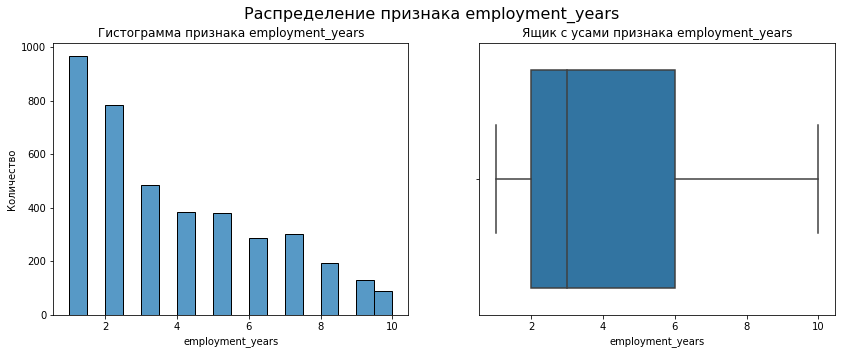

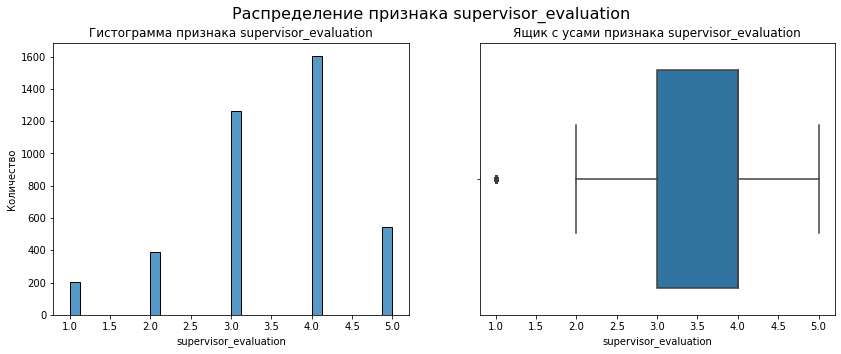

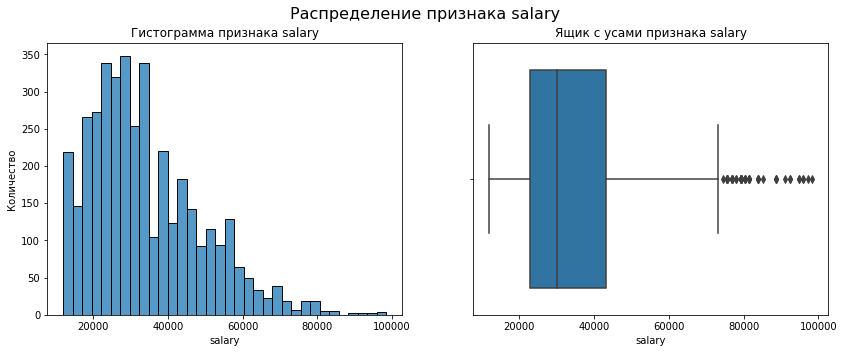

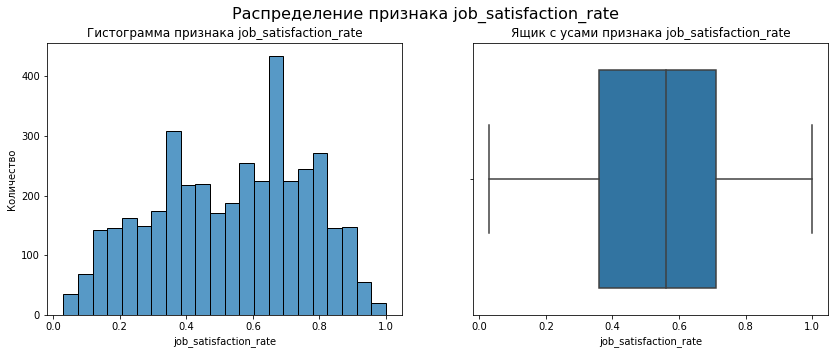

In [38]:
# Посмотрим на распределение количественных признаков
plot_num_columns(df_train_data)

Проверим не является ли в supervisor_evaluation значение 1.0 аномальным.

In [39]:
# Подсчет строк с соответствующим значением
count_of_1_0_values = (df_train_data['supervisor_evaluation'] == 1.0).sum()

print(f"Количество строк со значением 1.0 в столбце supervisor_evaluation: {count_of_1_0_values}")

Количество строк со значением 1.0 в столбце supervisor_evaluation: 201


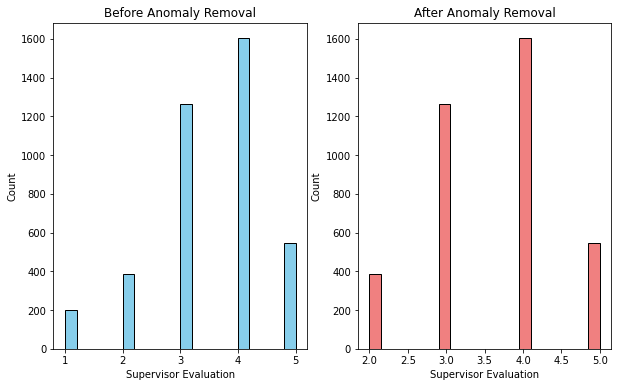

In [40]:
# Оценка влияния аномальных значений на распределение данных
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(df_train_data['supervisor_evaluation'], bins=20, color='skyblue', edgecolor='black')
plt.title('Before Anomaly Removal')
plt.xlabel('Supervisor Evaluation')
plt.ylabel('Count')

# Удаление аномальных значений
cleaned_data = df_train_data[df_train_data['supervisor_evaluation'] != 1.0]

# Оценка влияния после удаления аномальных значений
plt.subplot(1, 2, 2)
plt.hist(cleaned_data['supervisor_evaluation'], bins=20, color='lightcoral', edgecolor='black')
plt.title('After Anomaly Removal')
plt.xlabel('Supervisor Evaluation')
plt.ylabel('Count')
plt.show()

Учитывая, что данные состоят из 4000 строк, 5 % данных могут быть критичны, поэтому не будем удалять их

Стаж работы сотрудников в основном менее 2 лет, но есть сотрудники и с 10-летним стажем. Оценки от руководителей в основном на уровне 3.5, есть оценка 1 (5% от данных).
Основная часть сотрудников зарабатывает от 20-40 тысяч.
Уровень удовлетворенности в основном 0,5.
По признакам распределение не равномерное, есть значения сильно выбивающиеся из среднего.
Но удалять такие значения считаю не правильным, так как в этом случае будет не полная картина отображена.

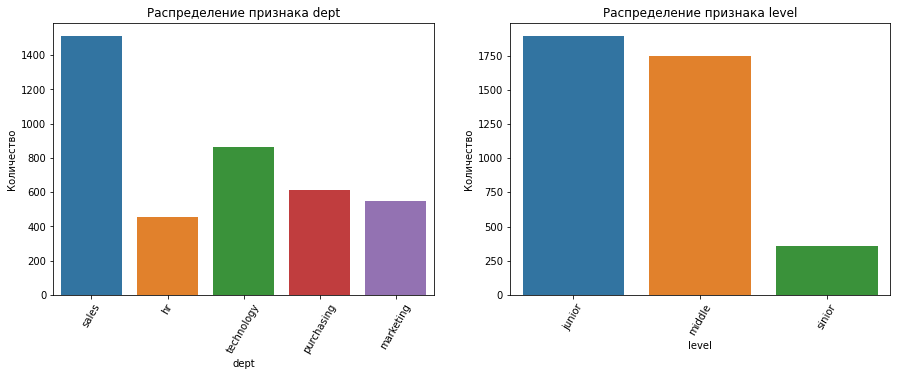

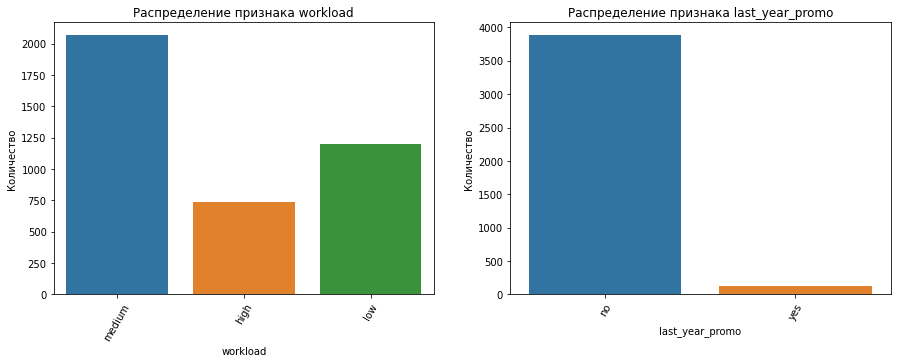

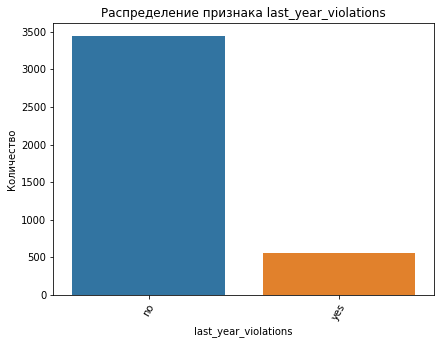

In [41]:
# Посмотрим на распределение категориальных признаков
plot_cat_columns(df_train_data)

In [42]:
# указание файла для проверки
numerical_data = df_train_data.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца id: 1.0
Значение теста Лиллиэфорса для столбца id: 0.0
Статистика теста Лиллиэфорса для столбца employment_years: 0.8413447460685429
Значение теста Лиллиэфорса для столбца employment_years: 0.0
Статистика теста Лиллиэфорса для столбца supervisor_evaluation: 0.9269998680518208
Значение теста Лиллиэфорса для столбца supervisor_evaluation: 0.0
Статистика теста Лиллиэфорса для столбца salary: 1.0
Значение теста Лиллиэфорса для столбца salary: 0.0
Статистика теста Лиллиэфорса для столбца job_satisfaction_rate: 0.5241063925851721
Значение теста Лиллиэфорса для столбца job_satisfaction_rate: 0.0


    На основе статистики теста Лиллиэфорса для каждого столбца, можно сделать вывод о том, что данные во всех столбцах не соответствуют нормальному распределению.
   Больше всего сотрудников в отделе продаж, уровень приваллирует junior, загруженность средняя, мало у кого есть повышение по карьерной лестнице и нарушение трудового договора.

Файл df_test_features

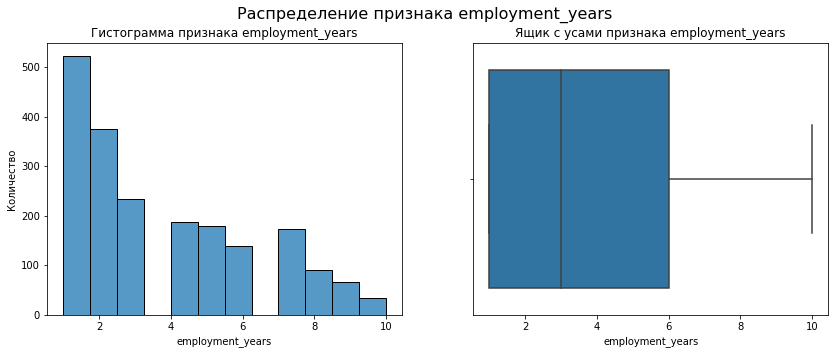

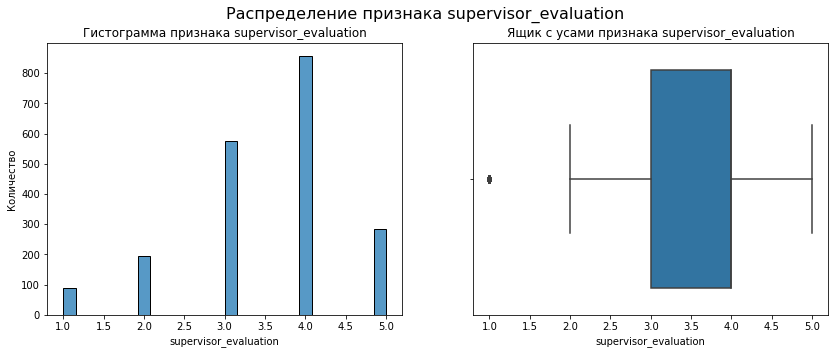

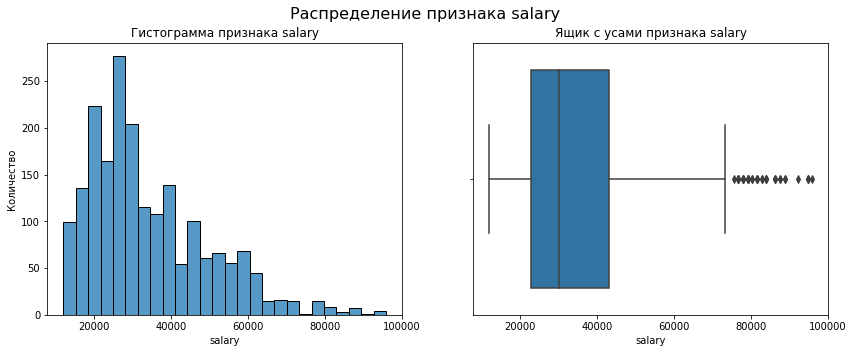

In [43]:
# Посмотрим на распределение количественных признаков
plot_num_columns(df_test_features)

Стаж работы сотрудников в основном менее 2 лет, но есть сотрудники и с 10-летним стажем. Оценки от руководителей в основном на уровне 4, есть оценка 1.
Основная часть сотрудников зарабатывает от 20-40 тысяч.

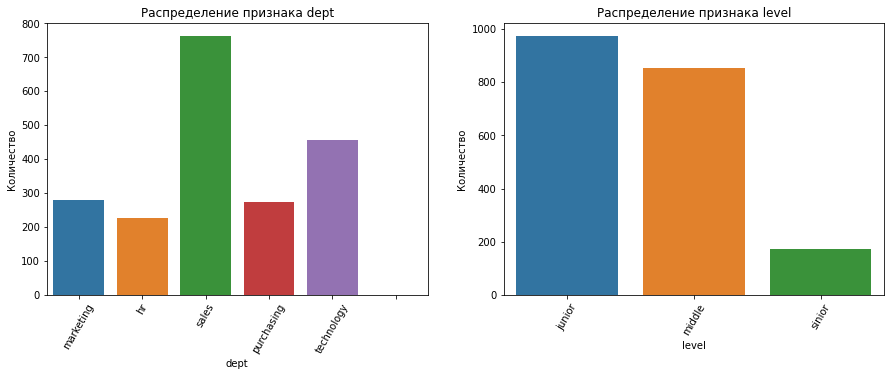

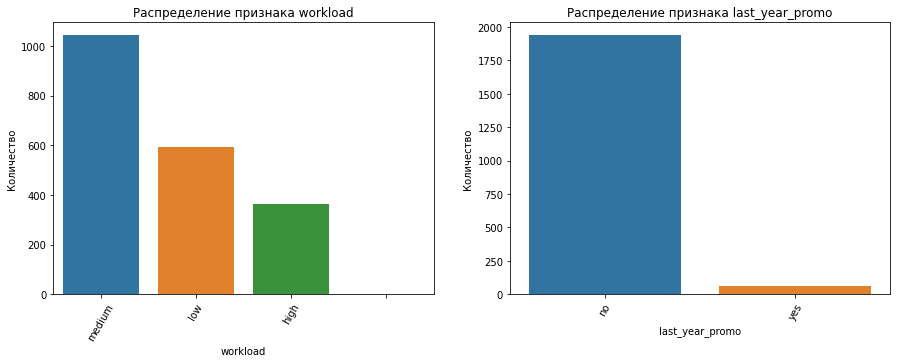

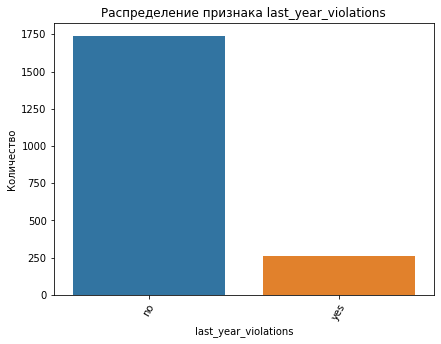

In [44]:
# Посмотрим на распределение категориальных признаков
plot_cat_columns(df_test_features)

In [45]:
# указание файла для проверки
numerical_data = df_test_features.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца id: 1.0
Значение теста Лиллиэфорса для столбца id: 0.0
Статистика теста Лиллиэфорса для столбца employment_years: 0.8413447460685429
Значение теста Лиллиэфорса для столбца employment_years: 0.0
Статистика теста Лиллиэфорса для столбца supervisor_evaluation: 0.9332498680518208
Значение теста Лиллиэфорса для столбца supervisor_evaluation: 0.0
Статистика теста Лиллиэфорса для столбца salary: 1.0
Значение теста Лиллиэфорса для столбца salary: 0.0


На основе статистики теста Лиллиэфорса для каждого столбца, можно сделать вывод о том, что данные во всех столбцах не соответствуют нормальному распределению.

Больше всего сотрудников в отделе продаж, уровень приваллирует junior, загруженность средняя, мало у кого есть повышение по карьерной лестнице и нарушение трудового договора.

Файл df_test_target

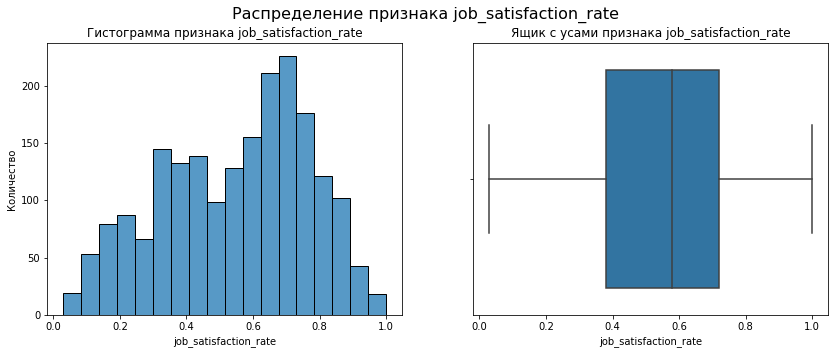

In [46]:
# Посмотрим на распределение количественных признаков
plot_num_columns(df_test_target)

In [47]:
# указание файла для проверки
numerical_data = df_test_target.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца id: 1.0
Значение теста Лиллиэфорса для столбца id: 0.0
Статистика теста Лиллиэфорса для столбца job_satisfaction_rate: 0.5263563925851722
Значение теста Лиллиэфорса для столбца job_satisfaction_rate: 0.0


На основе статистики теста Лиллиэфорса для каждого столбца, можно сделать вывод о том, что данные во всех столбцах не соответствуют нормальному распределению.

Уровень удовлетворённости сотрудника работой в компании распределен не равномерно. Средняя оценка 0.7.

На сколько видим все количественные признаки имеют не нормальное распределение. При создании модели необходимо стандартизировать и кодировать признаки.  

Проверим коррекляционный анализ по файлу df_train_data:

In [48]:
names_num_columns = df_train_data.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['employment_years',
 'supervisor_evaluation',
 'salary',
 'job_satisfaction_rate']

In [49]:
names_cat_columns = df_train_data.select_dtypes(exclude=[np.number]).columns.tolist()
names_cat_columns

['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']

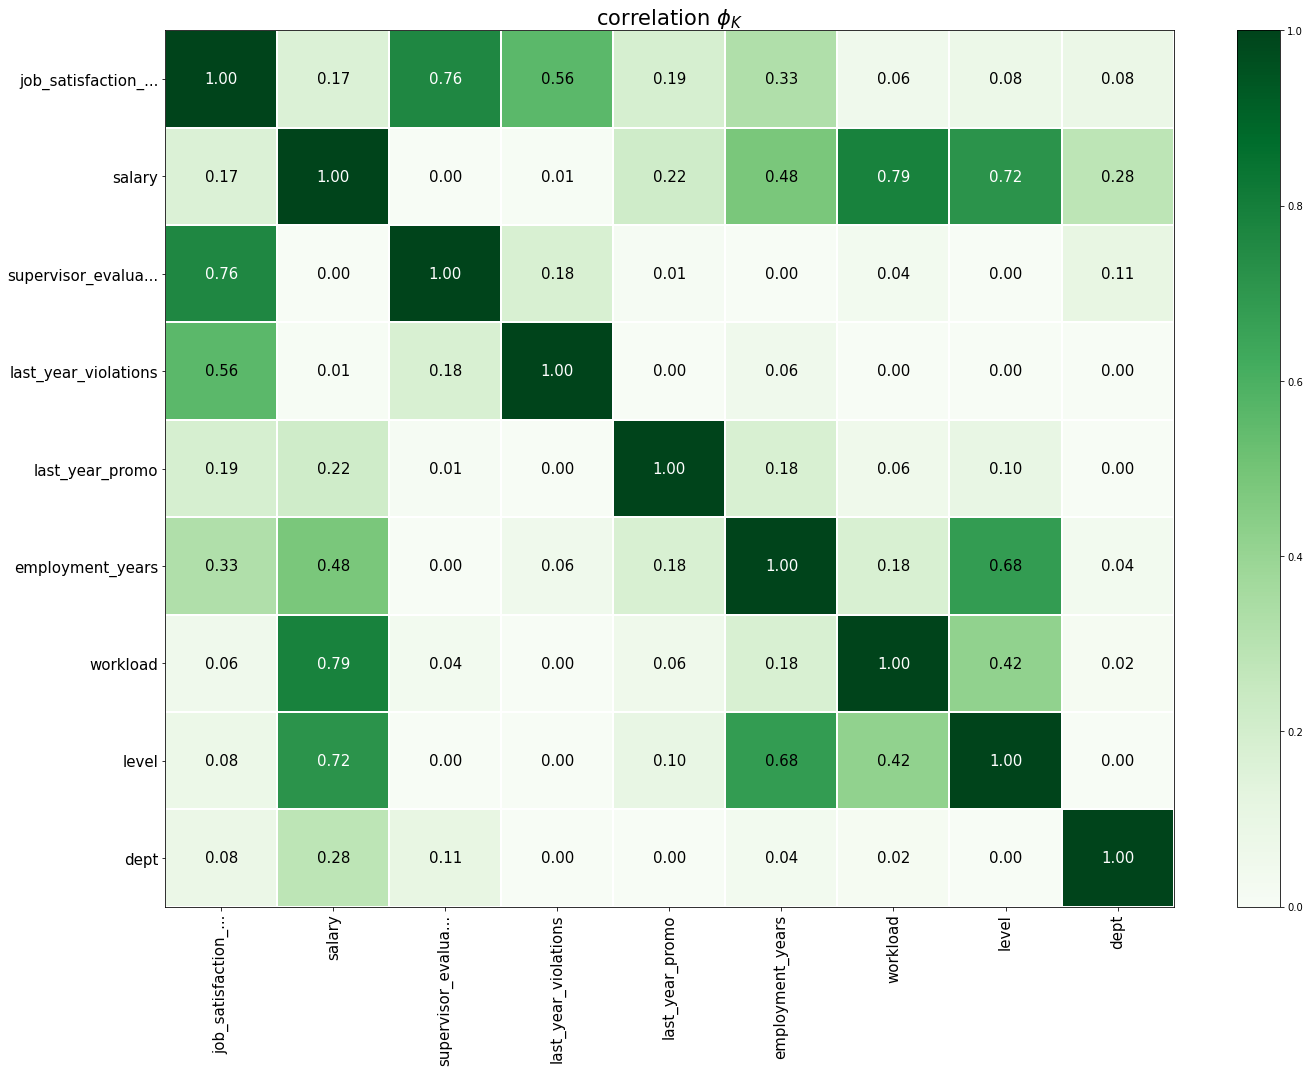

In [50]:
phik_overview = phik_matrix(df_train_data.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Можно сделать следующие выводы из анализа корреляции:

Уровень удовлетворенности сотрудника работой в компании имеет среднюю корреляцию с оценкой качества работы сотрудника, выставленной руководителем. Это говорит о том, что уровень удовлетворенности сотрудника и оценка его работы руководителем могут быть взаимосвязаны, но связь эта не является сильной.

Ежемесячная зарплата сотрудника коррелирует с уровнем загруженности сотрудника и уровнем его должности. Это означает, что уровень заработной платы сотрудника может быть связан с его уровнем занятости и должности в компании.

Оценка качества работы сотрудника, выставленная руководителем, коррелирует с уровнем удовлетворенности сотрудника работой в компании. Это указывает на то, что оценка работы сотрудника руководителем может быть связана с уровнем удовлетворенности сотрудника своей работой.

Показатель нарушения трудового договора за последний год коррелирует средне с уровнем удовлетворенности сотрудника работой в компании. Это может указывать на то, что нарушение трудового договора не имеет значительного влияния на уровень удовлетворенности сотрудника своей работой.

Длительность работы в компании (в годах) коррелирует с уровнем занимаемой должности и ежемесячной зарплатой сотрудника. Это может свидетельствовать о том, что чем дольше сотрудник работает в компании, тем выше может быть его должность и заработная плата.

Уровень загруженности сотрудника коррелирует с его ежемесячной зарплатой. Это может указывать на то, что уровень занятости сотрудника может быть связан с уровнем его заработной платы.

Уровень занимаемой должности коррелирует с ежемесячной зарплатой сотрудника и длительностью его работы в компании (в годах). Это может свидетельствовать о том, что уровень должности сотрудника может быть связан с его заработной платой и стажем работы в компании.

Проверим на мультиколлениарность

                             id  employment_years  supervisor_evaluation  \
id                     1.000000         -0.010971              -0.000598   
employment_years      -0.010971          1.000000              -0.003067   
supervisor_evaluation -0.000598         -0.003067               1.000000   
salary                -0.010381          0.463932               0.000561   
job_satisfaction_rate  0.002127          0.208295               0.691176   

                         salary  job_satisfaction_rate  
id                    -0.010381               0.002127  
employment_years       0.463932               0.208295  
supervisor_evaluation  0.000561               0.691176  
salary                 1.000000               0.114880  
job_satisfaction_rate  0.114880               1.000000  


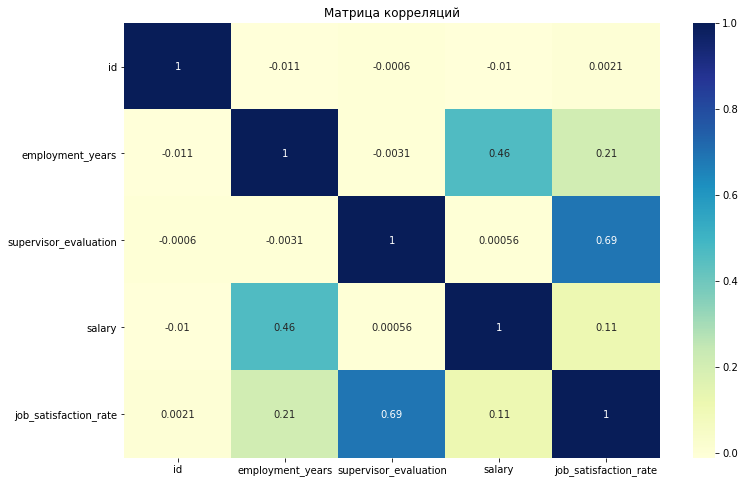

In [51]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = df_train_data.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

На основе данных о мультиколлинеарности, можно сделать следующий анализ:

Между признаками "employment_years" и "salary" существует относительно высокая корреляция (0.464). Это может свидетельствовать о наличии мультиколлинеарности между этими двумя признаками. В таком случае, модель, основанная на этих признаках, может столкнуться с проблемой нестабильности оценок коэффициентов и ухудшения качества прогнозов.

Также можно наблюдать относительно высокую корреляцию между признаками "supervisor_evaluation" и "job_satisfaction_rate" (0.7). Это также может указывать на возможную мультиколлинеарность, которая может повлиять на интерпретацию влияния этих признаков в модели.

Для борьбы с мультиколлинеарностью между "employment_years" и "salary", можно применить методы feature selection или feature engineering для исключения одного из коррелирующих признаков или их комбинации. Для "supervisor_evaluation" и "job_satisfaction_rate", также может потребоваться рассмотреть возможность их объединения или исключения одного из них при построении модели.

Значительная мультиколлинеарность может привести к нестабильности и неправильной интерпретации результатов модели, поэтому рекомендуется внимательно проанализировать и принять соответствующие меры для обработки этой проблемы перед построением модели.

Учтем это при проверке модели.

Вывод по анализу данных:
Исследовательский анализ данных дал следующие результаты:
Стаж работы сотрудников в основном менее 2 лет, но есть сотрудники и с 10-летним стажем. Оценки от руководителей в основном на уровне 3.5, есть оценка 1 (5% от данных). Основная часть сотрудников зарабатывает от 20-40 тысяч. Уровень удовлетворенности в основном 0,5. По признакам распределение не равномерное, есть значения сильно выбивающиеся из среднего. Но удалять такие значения считаю не правильным, так как в этом случае будет не полная картина отображена.
Больше всего сотрудников в отделе продаж, уровень приваллирует junior, загруженность средняя, мало у кого есть повышение по карьерной лестнице и нарушение трудового договора.
Уровень удовлетворённости сотрудника работой в компании распределен не равномерно. Средняя оценка 0.7.
На сколько видим все количественные признаки имеют не нормальное распределение. При создании модели необходимо стандартизировать и кодировать признаки.

Можно сделать следующие выводы из анализа корреляции:

Уровень удовлетворенности сотрудника работой в компании имеет среднюю корреляцию с оценкой качества работы сотрудника, выставленной руководителем. Это говорит о том, что уровень удовлетворенности сотрудника и оценка его работы руководителем могут быть взаимосвязаны, но связь эта не является сильной.

Ежемесячная зарплата сотрудника коррелирует с уровнем загруженности сотрудника и уровнем его должности. Это означает, что уровень заработной платы сотрудника может быть связан с его уровнем занятости и должности в компании.

Оценка качества работы сотрудника, выставленная руководителем, коррелирует с уровнем удовлетворенности сотрудника работой в компании. Это указывает на то, что оценка работы сотрудника руководителем может быть связана с уровнем удовлетворенности сотрудника своей работой.

Показатель нарушения трудового договора за последний год коррелирует средне с уровнем удовлетворенности сотрудника работой в компании. Это может указывать на то, что нарушение трудового договора не имеет значительного влияния на уровень удовлетворенности сотрудника своей работой.

Длительность работы в компании (в годах) коррелирует с уровнем занимаемой должности и ежемесячной зарплатой сотрудника. Это может свидетельствовать о том, что чем дольше сотрудник работает в компании, тем выше может быть его должность и заработная плата.

Уровень загруженности сотрудника коррелирует с его ежемесячной зарплатой. Это может указывать на то, что уровень занятости сотрудника может быть связан с уровнем его заработной платы.

Уровень занимаемой должности коррелирует с ежемесячной зарплатой сотрудника и длительностью его работы в компании (в годах). Это может свидетельствовать о том, что уровень должности сотрудника может быть связан с его заработной платой и стажем работы в компании.

На основе данных о мультиколлинеарности, можно сделать следующий анализ:

Между признаками "employment_years" и "salary" существует относительно высокая корреляция (0.464). Это может свидетельствовать о наличии мультиколлинеарности между этими двумя признаками. В таком случае, модель, основанная на этих признаках, может столкнуться с проблемой нестабильности оценок коэффициентов и ухудшения качества прогнозов.

Также можно наблюдать относительно высокую корреляцию между признаками "supervisor_evaluation" и "job_satisfaction_rate" (0.7). Это также может указывать на возможную мультиколлинеарность, которая может повлиять на интерпретацию влияния этих признаков в модели.

Для борьбы с мультиколлинеарностью между "employment_years" и "salary", можно применить методы feature selection или feature engineering для исключения одного из коррелирующих признаков или их комбинации. Для "supervisor_evaluation" и "job_satisfaction_rate", также может потребоваться рассмотреть возможность их объединения или исключения одного из них при построении модели.

Значительная мультиколлинеарность может привести к нестабильности и неправильной интерпретации результатов модели, поэтому рекомендуется внимательно проанализировать и принять соответствующие меры для обработки этой проблемы перед построением модели.

Учтем это при проверке модели.

## Подготовка данных

Подготовку признаков выполним в пайплайне, дополнив пайплайн шага предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика.

In [52]:
df_train_data['job_satisfaction_rate'].value_counts()

0.65    94
0.67    90
0.68    85
0.69    84
0.66    81
        ..
0.94     4
0.04     4
0.98     3
0.03     3
1.00     2
Name: job_satisfaction_rate, Length: 98, dtype: int64

In [53]:
df_train_data = df_train_data.set_index('id')
df_train_data.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [54]:
# Проверка на дубликаты
duplicate_rows = df_train_data[df_train_data.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Обнаружены дубликаты:
              dept   level workload  employment_years last_year_promo  \
id                                                                      
302957  purchasing  junior      low                 1              no   
752399       sales  middle      low                 7              no   
802286       sales  junior   medium                 1              no   
167303       sales  junior   medium                 1              no   
191841       sales  junior   medium                 1              no   
...            ...     ...      ...               ...             ...   
737303       sales  middle   medium                 3              no   
281204  technology  junior      low                 2              no   
261436       sales  middle      low                 3              no   
457950  technology  junior     high                 2              no   
957499       sales  junior   medium                 2              no   

       last_year_violations 

In [55]:
# Удаление дубликатов
df_train_data.drop_duplicates(inplace=True)

# Сохранение изменений в файле
df_train_data.to_csv('df_train_data.csv', index=False)

In [56]:
# Проверка на дубликаты
duplicate_rows = df_train_data[df_train_data.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Дубликатов не обнаружено


In [57]:
df_train_data

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20
...,...,...,...,...,...,...,...,...,...
424345,hr,sinior,high,6,no,no,4,80400,0.88
855240,sales,junior,medium,2,no,no,3,20400,0.27
533318,sales,middle,low,7,no,no,5,24000,0.76


In [58]:
# Проверка пропусков в данных и отображение количества пропусков по каждому признаку
missing_values = df_train_data.isnull().sum()
missing_values

dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

Обозначим, что мы имеем из данных:
df_train_data = X_trayn + y_train
df_test_features = X_test
df_test_target = y_test.

Файлы с тестовыми данными перемешаны, поэтому предварительно сделаем объединение таблиц и выделим X_test и y_test

In [59]:
df_test = df_test_features.merge(df_test_target, on='id', how='left')
df_test.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79
1,686555,hr,junior,medium,1,no,no,4,30000,0.72
2,467458,sales,middle,low,5,no,no,4,19200,0.64
3,418655,sales,middle,low,6,no,no,4,19200,0.60
4,789145,hr,middle,medium,5,no,no,5,40800,0.75


In [60]:
df_test = df_test.set_index('id')
df_test.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.79
686555,hr,junior,medium,1,no,no,4,30000,0.72
467458,sales,middle,low,5,no,no,4,19200,0.64
418655,sales,middle,low,6,no,no,4,19200,0.60
789145,hr,middle,medium,5,no,no,5,40800,0.75


In [61]:
# Проверка на дубликаты
duplicate_rows = df_test[df_test.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Обнаружены дубликаты:
              dept   level workload  employment_years last_year_promo  \
id                                                                      
523542   marketing  junior      low                 1              no   
770429          hr  junior   medium                 1              no   
493196       sales  junior      low                 1              no   
835127       sales  junior   medium                 1              no   
565390       sales  junior   medium                 1              no   
...            ...     ...      ...               ...             ...   
951029   marketing  junior   medium                 2              no   
779595       sales  junior   medium                 1              no   
535597  purchasing  junior      low                 1              no   
380255       sales  middle   medium                 8              no   
305653  technology  junior      low                 1              no   

       last_year_violations 

In [62]:
# Удаление дубликатов
df_test.drop_duplicates(inplace=True)

# Сохранение изменений в файле
df_test.to_csv('df_test.csv', index=False)

In [63]:
# Проверка на дубликаты
duplicate_rows = df_test[df_test.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Дубликатов не обнаружено


In [64]:
# категориальные признаки, которыми будем кодировать  OneHotEncoder
names_cat_columns = ['supervisor_evaluation','dept', 'last_year_promo', 'last_year_violations']

In [65]:
# категориальные признаки, которыми будем кодировать  OrdinalEncoder
names_ord_columns = ['level', 'workload']

In [66]:
# числовые признаки
names_num_columns = ['employment_years', 'salary']

In [67]:
# создание константы RANDOM_STATE
RANDOM_STATE = 42

# Разделение на обучающую и валидационную выборки
X_test = df_test.drop(['job_satisfaction_rate'], axis=1)
y_test = df_test['job_satisfaction_rate']
X_train = df_train_data.drop(['job_satisfaction_rate'], axis=1)
y_train = df_train_data['job_satisfaction_rate']

In [68]:
num_pipe = Pipeline(
    [
        ('Imputer_num', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
 )
num_pipe

Pipeline(steps=[('Imputer_num', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [69]:
cat_pipe = Pipeline(
    [
        ('Imputer_cat_1', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('Imputer_cat_2', SimpleImputer(missing_values=' ', strategy='most_frequent')),
        ('encoder_ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
 )
cat_pipe

Pipeline(steps=[('Imputer_cat_1', SimpleImputer(strategy='most_frequent')),
                ('Imputer_cat_2',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('encoder_ohe',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [70]:
ord_pipe = Pipeline(
    [
        ('Imputer_ord_1', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('Imputer_ord_2', SimpleImputer(missing_values=' ', strategy='most_frequent')),
        ('encoder_ord', OrdinalEncoder(categories = [['junior', 'middle', 'sinior'],
                                  ['low', 'medium', 'high']],
                       handle_unknown='use_encoded_value', unknown_value=np.nan))
    ]
 )
ord_pipe

Pipeline(steps=[('Imputer_ord_1', SimpleImputer(strategy='most_frequent')),
                ('Imputer_ord_2',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('encoder_ord',
                 OrdinalEncoder(categories=[['junior', 'middle', 'sinior'],
                                            ['low', 'medium', 'high']],
                                handle_unknown='use_encoded_value',
                                unknown_value=nan))])

In [71]:
data_preprocessor = ColumnTransformer(
    [
        ('num', num_pipe, names_num_columns),  # Заполнение пропусков в числовых признаках
        ('cat', cat_pipe, names_cat_columns),  # Кодирование категориальных признаков
        ('ord', ord_pipe, names_ord_columns)  # Кодирование отношений
    ],
    remainder='passthrough'
)

In [72]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
]) 

Подготовку признаков выполнили в пайплайне, дополнив пайплайн шага предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика.Полностью подготовили наш палайн к работе.

## Обучение моделей

Обучим как минимум две модели. Возьмем одну линейную модель, а в качестве второй — дерево решений. Подберем гиперпараметры как минимум для одной модели с помощью одного из известных нам инструментов.

In [73]:
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'model': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'model__max_depth': range(2, 15),
        'model__max_features': range(2, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
    },

    # словарь для модели LinearRegression()
    {
    'model': [LinearRegression()], 
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]

Создадим метрику, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE.

In [74]:
metrics=make_scorer(custom_metric,greater_is_better=False)

Выберем лучшую модель и проверим её качество. Выбор делаем на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»).

In [75]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring=metrics,
    n_jobs=-1,
)

In [76]:
best_model = grid_search.fit(X_train, y_train).best_estimator_
"Лучшая модель:", best_model

('Лучшая модель:',
 Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('num', MinMaxScaler(),
                                                   ['employment_years',
                                                    'salary']),
                                                  ('cat',
                                                   Pipeline(steps=[('Imputer_cat_1',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('Imputer_cat_2',
                                                                    SimpleImputer(missing_values=' ',
                                                                                  strategy='most_frequent')),
                                                                   ('encoder_ohe',
                                           

In [77]:
y_pred = grid_search.best_estimator_.predict(X_test)

In [78]:
# Получение предсказаний на тестовой выборке
y_test_pred = best_model.predict(X_test)

# Расчет метрики SMAPE
smape_value = custom_metric(y_test, y_test_pred)

print(f'Значение метрики SMAPE лучшей модели на тестовой выборке: {smape_value}')


Значение метрики SMAPE лучшей модели на тестовой выборке: 14.934531460369888


In [79]:
# Вычисление MAE и MSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Вывод результатов
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)


Mean Absolute Error (MAE): 0.06369252099691379
Mean Squared Error (MSE): 0.007190638402986165


Проверим лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки?

В качестве константной модели используем DummyRegressor:

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) - эта модель как раз создана для генерирования константных предсказаний.

Важно, чтобы результат тестирования нашей модели на тествой выборке был лучше, чем результат константной модели - в противном случае наша модель является бесполезной, так как все наши усилия над проектом не принесли результата, а может, просто предсказывющая среднее на train, делает нашу работу лучше.

In [80]:
# Создание константной модели
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

# Оценка качества константной модели
dummy_pred = dummy_model.predict(X_test)
dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_mse = mean_squared_error(y_test, dummy_pred)

# Вывод результатов оценки константной модели
print("Mean Absolute Error of Dummy Model (MAE):", dummy_mae)
print("Mean Squared Error of Dummy Model (MSE):", dummy_mse)

# Сравнение качества лучшей модели с константной моделью
if mae < dummy_mae and mse < dummy_mse:
    print("Лучшая модель прошла проверку на адекватность: она предсказывает лучше, чем простая константная модель.")
else:
    print("Лучшая модель не прошла проверку на адекватность: ее предсказания не лучше, чем простая константная модель.")

Mean Absolute Error of Dummy Model (MAE): 0.19017216620232316
Mean Squared Error of Dummy Model (MSE): 0.049198765657715623
Лучшая модель прошла проверку на адекватность: она предсказывает лучше, чем простая константная модель.


Обучили две модели. Взяли одну линейную модель, а в качестве второй — дерево решений. Подобрали гиперпараметры как минимум для одной модели с помощью одного из известных нам инструментов.
Лучшая модель и её параметры:DecisionTreeRegressor(max_depth=13, max_features=13, random_state=42) 
Значение метрики SMAPE лучшей модели на тестовой выборке: 14.934531460369888 
MAE: 0.06369252099691379
MSE: 0.007190638402986165
Метрики дают хороший показатель предсказаний.
Лучшая модель прошла проверку на адекватность: она предсказывает лучше, чем простая константная модель.

## Оформление выводов

   *Промежуточный Вывод*:
Мы загрузили данные и ознакомились с ними. Можно заметить, что в данных присутствуют как количественные так и категориальные признаки. В данных пропуски заполним в паплайне, дубликатов не обнаруженно.
  Все количественные признаки имеют не нормальное распределение. При создании модели необходимо стандартизировать и кодировать признаки.
Подготовку признаков выполнили в пайплайне, дополнив пайплайн шага предобработки. При кодировании учитываем особенности признаков и моделей и используем как минимум два кодировщика.Полностью подготовили наш палайн к работе.
  Обучили две модели. Взяли одну линейную модель, а в качестве второй — дерево решений. Подобрали гиперпараметры как минимум для одной модели с помощью одного из известных нам инструментов.
Лучшая модель и её параметры:DecisionTreeRegressor(max_depth=13, max_features=13, random_state=42) 
Значение метрики SMAPE лучшей модели на тестовой выборке: 14.934531460369888 
MAE: 0.06369252099691379
MSE: 0.007190638402986165
Метрики дают хороший показатель предсказаний.

## Задача 2: предсказание увольнения сотрудника из компании

## Загрузка данных

1.2 Проверим, что данные в таблицах соответствуют описанию. Исследованием и объединением данных займёмся позже.
Тренировочная выборка:
train_quit.csv
Входные признаки тестовой выборки те же, что и в прошлой задаче:
test_features.csv
Целевой признак тестовой выборки:
test_target_quit.csv

In [81]:
try:
    df_train2_data = pd.read_csv('/datasets/train_quit.csv', sep=',', decimal='.')
except:
    df_train2_data = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\train_quit.csv', sep=',', decimal='.')
    
df_train2_data.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [82]:
try:
    df_test_features = pd.read_csv('/datasets/test_features.csv', sep=',', decimal='.')
except:
    df_test_features = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\test_features.csv', sep=',', decimal='.')
    
df_test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [83]:
try:
    df_test_target_quit = pd.read_csv('/datasets/test_target_quit.csv', sep=',', decimal='.')
except:
    df_test_target_quit = pd.read_csv(r'C:\Users\user\Desktop\сборный 2\test_target_quit.csv', sep=',', decimal='.')
    
df_test_target_quit.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [84]:
df_train2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [85]:
df_test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [86]:
df_test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


Данные в таблице требуют предобработки, требуется проверить явные и не явные дубликаты.

##  Предобработка данных 2

Файл df_train2_data

In [87]:
# Отредактируем имена столбцов
edit_names_columns(df_train2_data)

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'quit'],
      dtype='object')


In [88]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_train2_data)

Количество пропусков:
id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['employment_years', 'supervisor_evaluation', 'salary']

Категориальные признаки: ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit']



In [89]:
# Проверим данные в столбце dept на неявные дубликаты
df_train2_data['dept'].sort_values().unique()

array(['hr', 'marketing', 'purchasing', 'sales', 'technology'],
      dtype=object)

In [90]:
# Проверим данные в столбце level на неявные дубликаты
df_train2_data['level'].sort_values().unique()

array(['junior', 'middle', 'sinior'], dtype=object)

In [91]:
# Проверим данные в столбце workload на неявные дубликаты
df_train2_data['workload'].sort_values().unique()

array(['high', 'low', 'medium'], dtype=object)

In [92]:
# Проверим данные в столбце last_year_promo на неявные дубликаты
df_train2_data['last_year_promo'].sort_values().unique()

array(['no', 'yes'], dtype=object)

In [93]:
# Проверим данные в столбце last_year_violations на неявные дубликаты
df_train2_data['last_year_violations'].sort_values().unique()

array(['no', 'yes'], dtype=object)

In [94]:
# Проверим данные в столбце quit на неявные дубликаты
df_train2_data['quit'].sort_values().unique()

array(['no', 'yes'], dtype=object)

Файл df_test_features мы обрабатывали в первой задаче, поэтому повторно к нему возвращаться не будем.

Файл df_test_target_quit

In [95]:
# Отредактируем имена столбцов
edit_names_columns(df_test_target_quit)

Index(['id', 'quit'], dtype='object')


In [96]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(df_test_target_quit)

Количество пропусков:
id      0
quit    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: []

Категориальные признаки: ['quit']



In [97]:
# Проверим данные в столбце dept на неявные дубликаты
df_test_target_quit['quit'].sort_values().unique()

array(['no', 'yes'], dtype=object)

Мы загрузили данные и ознакомились с ними. Можно заметить, что в данных присутствуют как количественные так и категориальные признаки. В данных пропусков, дубликатов явных и не явных не обнаруженно.

## Исследовательский анализ данных 2

Проведем исследовательский анализ данных.

Файл df_train2_data

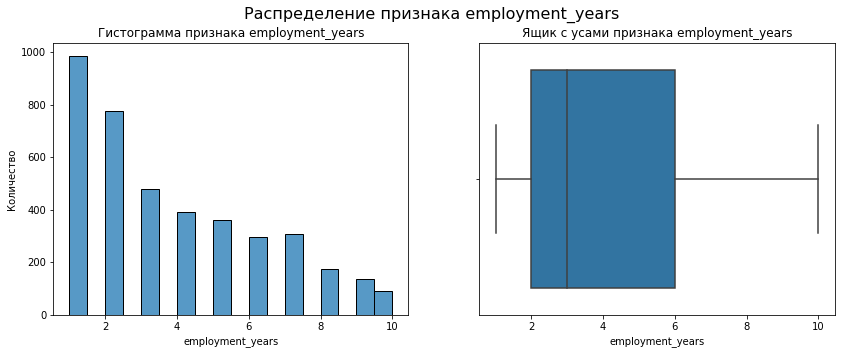

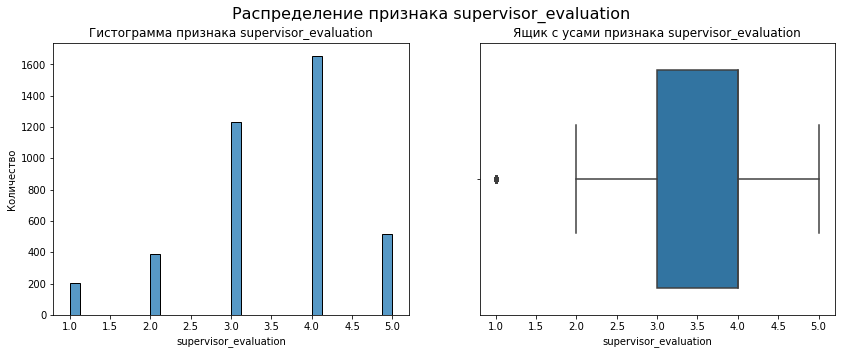

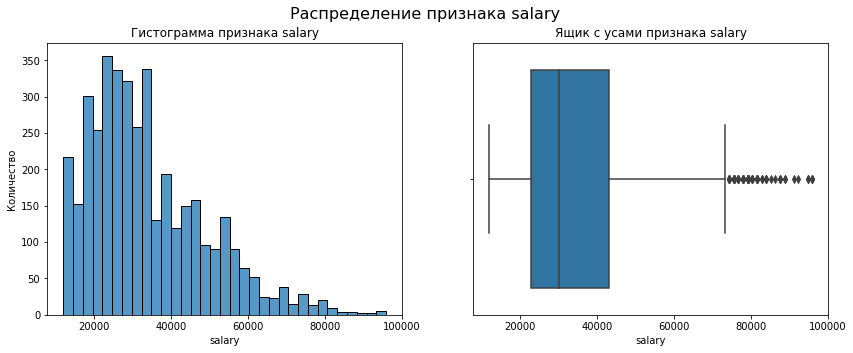

In [98]:
# Посмотрим на распределение количественных признаков
plot_num_columns(df_train2_data)

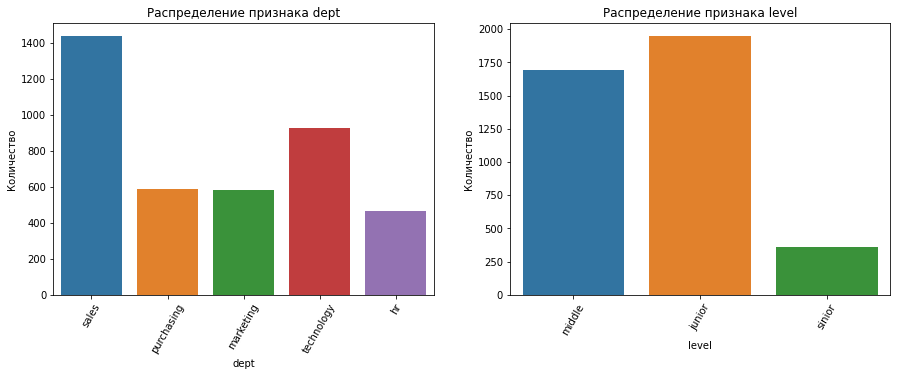

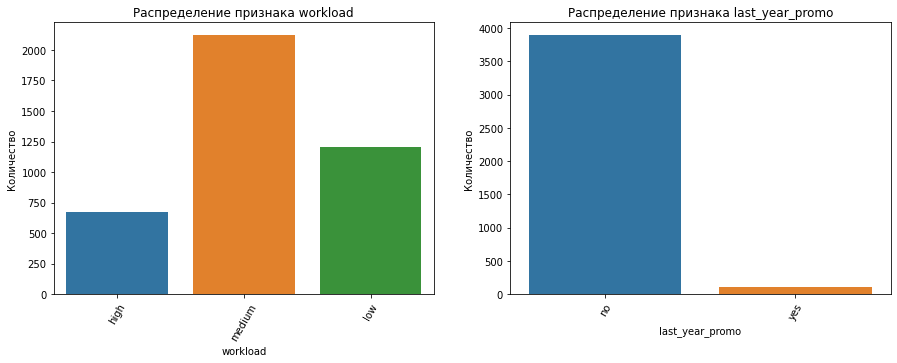

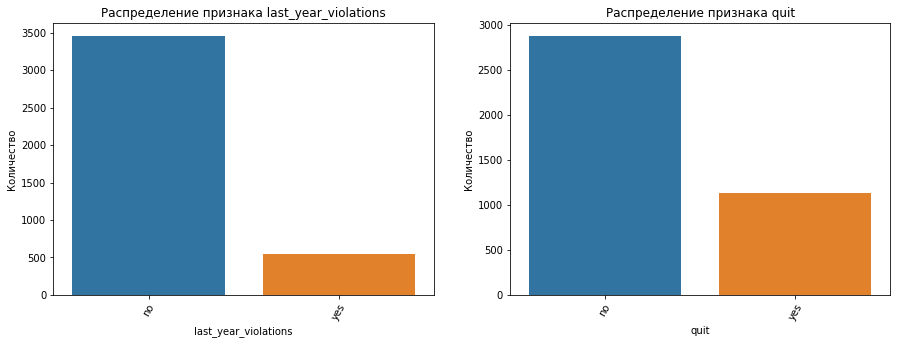

In [99]:
# Посмотрим на распределение категориальных признаков
plot_cat_columns(df_train2_data)

In [100]:
# Проверка на неявные дубликаты
duplicates = df_train2_data.duplicated()

# Подсчет количества неявных дубликатов
num_duplicates = duplicates.sum()

# Вывод результата
"Количество неявных дубликатов в df_train2_data:", num_duplicates

('Количество неявных дубликатов в df_train2_data:', 0)

In [101]:
# указание файла для проверки
numerical_data = df_train2_data.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца id: 1.0
Значение теста Лиллиэфорса для столбца id: 0.0
Статистика теста Лиллиэфорса для столбца employment_years: 0.8413447460685429
Значение теста Лиллиэфорса для столбца employment_years: 0.0
Статистика теста Лиллиэфорса для столбца supervisor_evaluation: 0.9267498680518208
Значение теста Лиллиэфорса для столбца supervisor_evaluation: 0.0
Статистика теста Лиллиэфорса для столбца salary: 1.0
Значение теста Лиллиэфорса для столбца salary: 0.0


Согласно тесту Лиллиэфорса данные распределены не равномерно

Средняя длительность работы сотрудников в компании составляет 3 года.
Наибольшее повышение в должности за последний год получило очень малое количество сотрудников.
Мало сотрудников нарушило трудовой договор за последний год.
Уровень должности сотрудника обычно прогрессирует от 'junior' к 'middle', а затем к 'senior'.
Большинство сотрудников имеют среднюю загруженность, затем идут сотрудники с низкой загруженностью, и меньше всего сотрудников с высокой загруженностью.
Средняя оценка качества работы сотрудника, выставленная руководителем, составляет 3,5.
Ежемесячная зарплата сотрудника варьируется от 20000 до 40000.
Большинство сотрудников работают в отделе продаж, затем в техническом отделе, и остальные находятся на равных позициях, при этом отдел кадров является самым маленьким.
За последий период времени уволилось более 1000 человек.

Проверим коррекляционный анализ по файлу df_train2_data:

In [102]:
names_num_columns = df_train2_data.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['employment_years', 'supervisor_evaluation', 'salary']

In [103]:
names_cat_columns = df_train2_data.select_dtypes(exclude=[np.number]).columns.tolist()
names_cat_columns

['dept',
 'level',
 'workload',
 'last_year_promo',
 'last_year_violations',
 'quit']

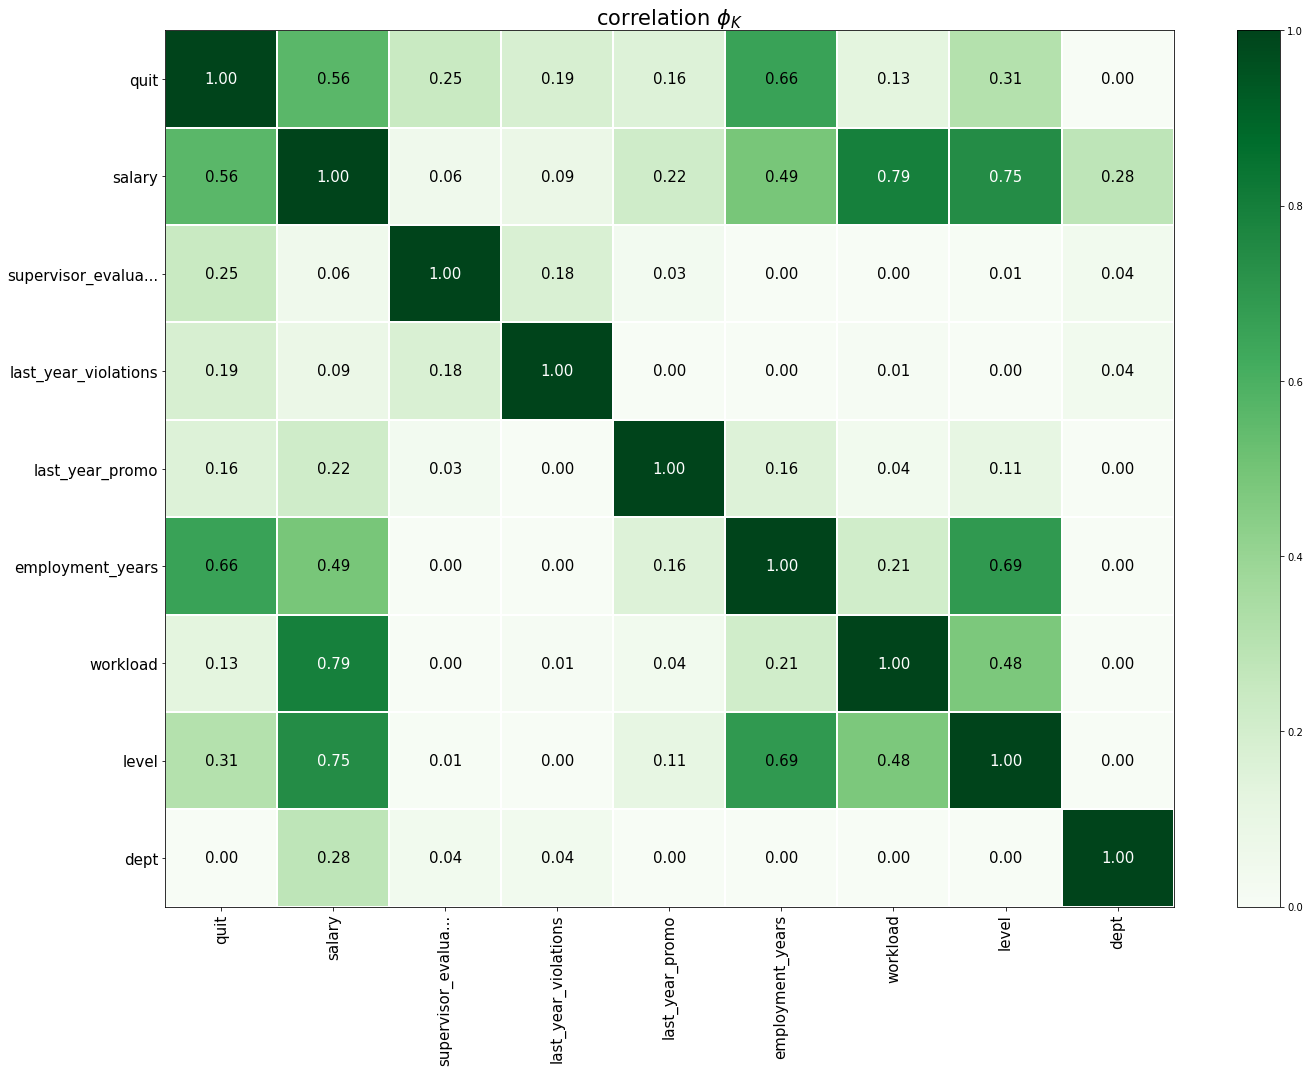

In [104]:
phik_overview = phik_matrix(df_train2_data.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Проверим на мультиколлениарность

                             id  employment_years  supervisor_evaluation  \
id                     1.000000          0.050455              -0.017068   
employment_years       0.050455          1.000000              -0.005991   
supervisor_evaluation -0.017068         -0.005991               1.000000   
salary                 0.017090          0.468951               0.039829   

                         salary  
id                     0.017090  
employment_years       0.468951  
supervisor_evaluation  0.039829  
salary                 1.000000  


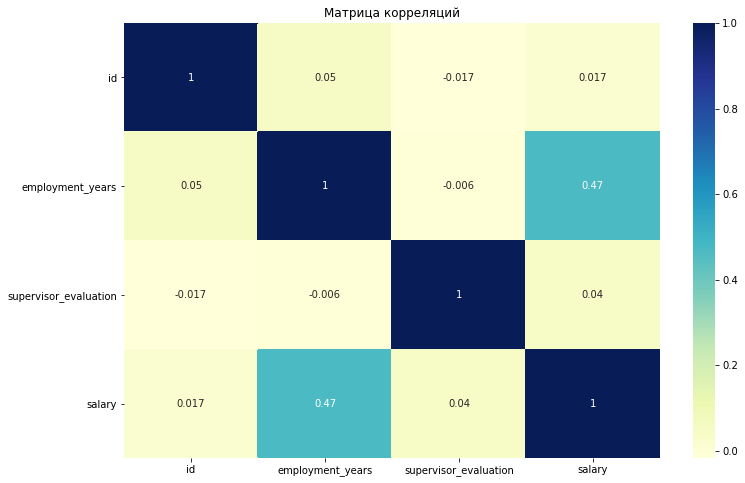

In [105]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = df_train2_data.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

Мультиколлениарность отсутствует

Файл df_test_features мы обрабатывали в первой задаче, поэтому повторно к нему возвращаться не будем.

Файл df_test_target_quit

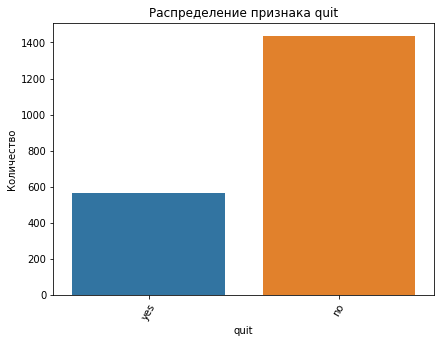

In [106]:
# Посмотрим на распределение категориальных признаков
plot_cat_columns(df_test_target_quit)

In [107]:
# указание файла для проверки
numerical_data = df_test_target_quit.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца id: 1.0
Значение теста Лиллиэфорса для столбца id: 0.0


Составим портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

In [108]:
# Фильтрация уволившихся сотрудников
df_quit_yes = df_train2_data[df_train2_data['quit'] == 'yes']

# Сохранение в отдельный файл 
df_quit_yes.to_csv('уволившиеся_сотрудники.csv', index=False)

Анализ категориальных признаков

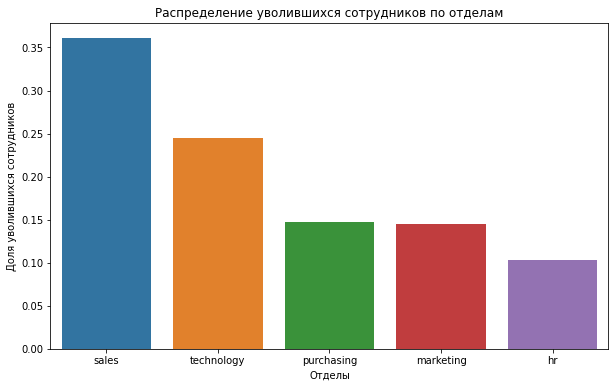

In [109]:
# Анализ признака 'dept' (отдел)
dept_counts = df_quit_yes['dept'].value_counts(normalize=True)  
plt.figure(figsize=(10, 6))
sns.barplot(x=dept_counts.index, y=dept_counts.values)
plt.title('Распределение уволившихся сотрудников по отделам')
plt.xlabel('Отделы')
plt.ylabel('Доля уволившихся сотрудников')
plt.show()

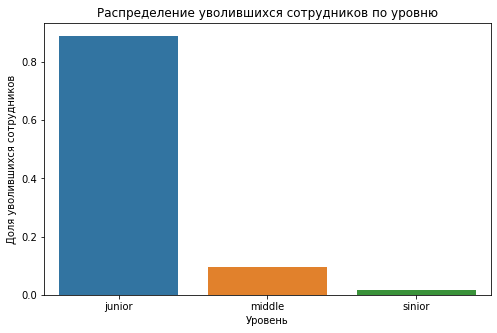

In [110]:
# Анализ признака 'level' (уровень)
level_counts = df_quit_yes['level'].value_counts(normalize=True) 
plt.figure(figsize=(8, 5))
sns.barplot(x=level_counts.index, y=level_counts.values)
plt.title('Распределение уволившихся сотрудников по уровню')
plt.xlabel('Уровень')
plt.ylabel('Доля уволившихся сотрудников')
plt.show()

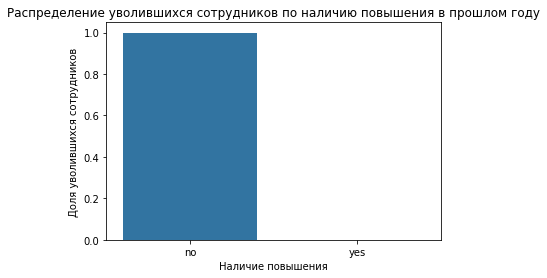

In [111]:
# Анализ признака 'last_year_promo' (последнее повышение в прошлом году)
last_year_promo_counts = df_quit_yes['last_year_promo'].value_counts(normalize=True) 
plt.figure(figsize=(6, 4))
sns.barplot(x=last_year_promo_counts.index, y=last_year_promo_counts.values)
plt.title('Распределение уволившихся сотрудников по наличию повышения в прошлом году')
plt.xlabel('Наличие повышения')
plt.ylabel('Доля уволившихся сотрудников')
plt.show()

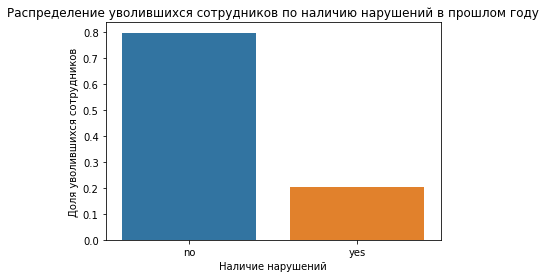

In [112]:
# Анализ признака 'last_year_violations' (наличие нарушений в прошлом году)
violations_counts = df_quit_yes['last_year_violations'].value_counts(normalize=True) 
plt.figure(figsize=(6, 4))
sns.barplot(x=violations_counts.index, y=violations_counts.values)
plt.title('Распределение уволившихся сотрудников по наличию нарушений в прошлом году')
plt.xlabel('Наличие нарушений')
plt.ylabel('Доля уволившихся сотрудников')
plt.show()

Анализ дискретных признаков

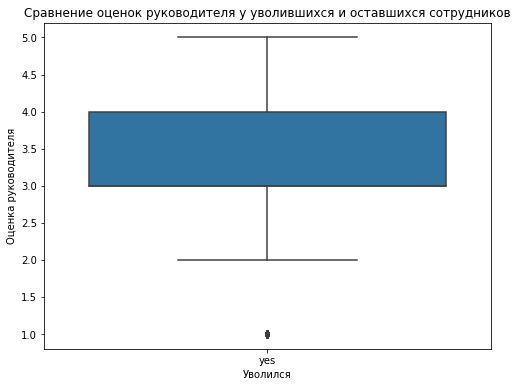

In [113]:
# Анализ признака 'supervisor_evaluation' (оценка руководителя)
plt.figure(figsize=(8, 6))
sns.boxplot(x='quit', y='supervisor_evaluation', data=df_quit_yes)
plt.title('Сравнение оценок руководителя у уволившихся и оставшихся сотрудников')
plt.xlabel('Уволился')
plt.ylabel('Оценка руководителя')
plt.show()

Анализ непрерывных признаков

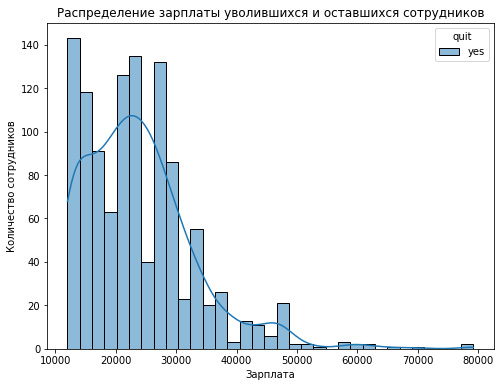

In [114]:
# Анализ признака 'salary' (зарплата)
plt.figure(figsize=(8, 6))
sns.histplot(data=df_quit_yes, x='salary', kde=True, hue='quit')
plt.title('Распределение зарплаты уволившихся и оставшихся сотрудников')
plt.xlabel('Зарплата')
plt.ylabel('Количество сотрудников')
plt.show() 

<function matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

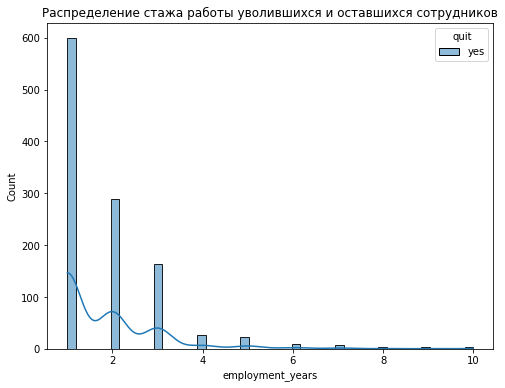

In [115]:
# Анализ признака 'employment_years' (стаж работы)
plt.figure(figsize=(8, 6))
sns.histplot(df_quit_yes, x='employment_years', kde=True, hue='quit')
plt.title('Распределение стажа работы уволившихся и оставшихся сотрудников')
plt.xlabel 

35% процентов уволившихся сотрудников работало в отделе продаж, 25% в тех. отделе, по 15 % в маркетинге и закупки и 10% в отделе кадров.
85 % имеют уровень junior, без повышений, 79% не имеют нарушений трудового договора, оценка руководителя 4.
Уровень зарплаты разный, есть как на минимальных, так и на выше среднего уровне уволившиеся сотрудники.
Основной стаж в компании редко превышает 3 года. 

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверим это утверждение: визуализируем и сравним распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используем данные с обоими целевыми признаками тестовой выборки.

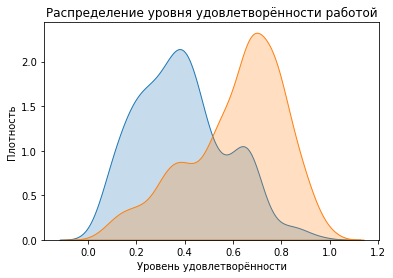

In [116]:
# Объединение данных по индексам id
df = df_test_target_quit.set_index('id').join(df_test_target.set_index('id'))

# Визуализация распределений уровня удовлетворённости работой для ушедших и оставшихся сотрудников
sns.kdeplot(df[df['quit'] == 'yes']['job_satisfaction_rate'], label='Ушедшие сотрудники', shade=True)
sns.kdeplot(df[df['quit'] == 'no']['job_satisfaction_rate'], label='Оставшиеся сотрудники', shade=True)
plt.title('Распределение уровня удовлетворённости работой')
plt.xlabel('Уровень удовлетворённости')
plt.ylabel('Плотность')
plt.show()

Уровень удовлетворенности уволившихся сотрудников ниже, чем у оставшихся. Также заметно, что у уволившихся сотрудников оценка не превышает 1.0. Из этого можем также сделать вывод, что сотрудник, который может уволиться будет ставить средние оценки, без внимания к вопросам.

##   Добавление нового входного признака

Допустим, job_satisfaction_rate и quit действительно связаны и мы получили необходимое значение метрики в первой задаче. Тогда добавим job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [117]:
# Подгрузим сохраненную модель и предскажем job_satisfaction_rate для второй задачи
best_model = grid_search.best_estimator_  
df_train2_data['job_satisfaction_rate'] = best_model.predict(df_train2_data.drop('quit', axis=1))  # Добавим предсказания в тренировочные данные
df_test_features['job_satisfaction_rate'] = best_model.predict(df_test_features)  # Добавим предсказания в данные для тестирования


In [118]:
df_train2_data.head()  # Вывод первых строк тренировочных данных с предсказанными значениями job_satisfaction_rate
df_test_features.head() # Вывод первых строк данных для тестирования с предсказанными значениями job_satisfaction_rate

# Для сохранения данных в файл
df_train2_data.to_csv('train_data_with_predictions.csv', index=False)  # Сохранение тренировочных данных с предсказанными значениями в файл
df_test_features.to_csv('test_data_with_predictions.csv', index=False)  # Сохранение данных для тестирования с предсказанными значениями в файл

## Подготовка данных 2

Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

In [119]:
df_train2_data = df_train2_data.set_index('id')
df_train2_data.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.600000
814010,sales,junior,medium,2,no,no,4,27600,no,0.845000
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.360435
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [120]:
# Проверка на дубликаты
duplicate_rows = df_train2_data[df_train2_data.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Обнаружены дубликаты:
              dept   level workload  employment_years last_year_promo  \
id                                                                      
873412  technology  junior   medium                 2              no   
749683       sales  middle      low                 8              no   
689526   marketing  middle      low                 6              no   
786443  purchasing  middle      low                 6              no   
362060       sales  junior      low                 1              no   
...            ...     ...      ...               ...             ...   
632886       sales  junior      low                 3              no   
387733   marketing  middle   medium                 5              no   
588809       sales  junior   medium                 4              no   
672059       sales  middle     high                 9              no   
853842       sales  junior   medium                 2              no   

       last_year_violations 

In [121]:
# Удаление дубликатов
df_train2_data.drop_duplicates(inplace=True)

# Повторная проверка наличия дубликатов после удаления
duplicate_rows_after_removal = df_train2_data[df_train2_data.duplicated()]

if duplicate_rows_after_removal.shape[0] == 0:
    print("Дубликаты успешно удалены")
else:
    print("Не удалось удалить все дубликаты")

Дубликаты успешно удалены


In [122]:
# Проверка пропусков в данных и отображение количества пропусков по каждому признаку
missing2_values = df_train2_data.isnull().sum()
missing2_values

dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
job_satisfaction_rate    0
dtype: int64

 Обозначим, что мы имеем из данных:

df_train2_data = X_trayn + y_train

df_test_features = X_test
  
df_test_target = y_test

Файлы с тестовыми данными перемешаны, поэтому предварительно сделаем объединение таблиц и выделим X_test и y_test

In [123]:
df_test_second = df_test_features.merge(df_test_target_quit, on='id', how='left')

In [124]:
# Проверка на дубликаты
duplicate_rows = df_test_second[df_test_second.duplicated()]

if duplicate_rows.shape[0] == 0:
    print("Дубликатов не обнаружено")
else:
    print("Обнаружены дубликаты:")
    print(duplicate_rows)

Дубликатов не обнаружено


In [125]:
names_cat_columns = ['dept', 'last_year_promo', 'last_year_violations', 'supervisor_evaluation']

In [126]:
names_ohe_columns = ['level', 'workload']

In [127]:
names_num_columns = ['employment_years', 'salary', 'job_satisfaction_rate']

In [128]:
# создание константы RANDOM_STATE
RANDOM_STATE = 42

# Разделение на обучающую и тестовую выборки
X_test = df_test_second.drop(['quit'], axis=1)
y_test = df_test_second['quit']
X_train = df_train2_data.drop(['quit'], axis=1)
y_train = df_train2_data['quit']

In [129]:
num_pipe = Pipeline(
    [
        ('Imputer_num', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
 )
num_pipe

Pipeline(steps=[('Imputer_num', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [130]:
cat_pipe = Pipeline(
    [
        ('Imputer_cat_1', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('Imputer_cat_2', SimpleImputer(missing_values=' ', strategy='most_frequent')),
        ('encoder_ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
 )
cat_pipe

Pipeline(steps=[('Imputer_cat_1', SimpleImputer(strategy='most_frequent')),
                ('Imputer_cat_2',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('encoder_ohe',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

In [131]:
ord_pipe = Pipeline(
    [
        ('Imputer_ord_1', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('Imputer_ord_2', SimpleImputer(missing_values=' ', strategy='most_frequent')),
        ('encoder_ord', OrdinalEncoder(categories = [['junior', 'middle', 'sinior'],
                                  ['low', 'medium', 'high']],
                       handle_unknown='use_encoded_value', unknown_value=np.nan))
    ]
 )
ord_pipe

Pipeline(steps=[('Imputer_ord_1', SimpleImputer(strategy='most_frequent')),
                ('Imputer_ord_2',
                 SimpleImputer(missing_values=' ', strategy='most_frequent')),
                ('encoder_ord',
                 OrdinalEncoder(categories=[['junior', 'middle', 'sinior'],
                                            ['low', 'medium', 'high']],
                                handle_unknown='use_encoded_value',
                                unknown_value=nan))])

In [132]:
data_preprocessor = ColumnTransformer(
    [
        ('num', num_pipe, names_num_columns),  # Заполнение пропусков в числовых признаках
        ('cat', cat_pipe, names_cat_columns),  # Кодирование категориальных признаков
        ('ord', ord_pipe, names_ord_columns)  # Кодирование отношений
    ],
    remainder='passthrough'
)

In [133]:
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
]) 

## Обучение модели

Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.
Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC ≥ 0.91 ≥ 0.91 на тестовой выборке. Напомним: отбор признаков часто помогает улучшить метрику.

In [134]:
param_grid_dt = {
    'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
    'model__max_depth': range(2, 20),
    'model__max_features': range(2, 20),
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
}

param_grid_lr = {
    'model': [LogisticRegression(solver='liblinear', random_state=RANDOM_STATE)],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
}

param_grid_rf = {
    'model': [RandomForestClassifier(random_state=RANDOM_STATE)],
    'model__max_depth': range(2, 20),
    'model__max_features': range(2, 20),
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
}

In [135]:
param_grid_combined = [param_grid_dt, param_grid_lr, param_grid_rf]

In [136]:
grid_search_2 = GridSearchCV(
    pipe_final,
    param_grid_combined,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [137]:
best_model = grid_search_2.fit(X_train, y_train).best_estimator_

In [138]:
print('Лучшая модель и её параметры:\n\n', grid_search_2.best_estimator_, '\n')
print ('Метрика лучшей модели на тестовой выборке:', grid_search_2.best_score_, '\n')

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', 'passthrough',
                                                  ['employment_years', 'salary',
                                                   'job_satisfaction_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer_cat_1',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Imputer_cat_2',
                                                                   SimpleImputer(missing_values=' ',
                                                                                 strategy='most_frequent')),
                                                                  ('encoder_ohe',
                  

In [139]:
y_proba = grid_search_2.best_estimator_.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC = {roc_auc:.3f}')

ROC-AUC = 0.921


Проверим лучшую модель на адекватность, сравнив качество её предсказаний с качеством модели, которая предсказывала бы константу - вдруг окажется, что не было бы большого смысла заниматься созданием новых признаков, тюнингом и кросс-валидацией моделей, если можно было бы просто предсказывать среднее значение тренировочной выборки?

In [140]:
# Создание Dummy модели
dummy_model = DummyClassifier(strategy='stratified')
dummy_model.fit(X_train, y_train)

# Оценка качества Dummy модели
dummy_proba = dummy_model.predict_proba(X_test)[:, 1]  # Использование вероятностной оценки для класса 1
dummy_roc_auc = roc_auc_score(y_test, dummy_proba)

# Вывод результата оценки
print("ROC-AUC для Dummy модели:", dummy_roc_auc)

# Сравнение качества лучшей модели с Dummy моделью
if roc_auc > dummy_roc_auc:
    print("Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.")
else:
    print("Лучшая модель не прошла проверку на адекватность: ее качество не превосходит качество Dummy модели.")


ROC-AUC для Dummy модели: 0.48581807226535495
Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.


## Выводы

Сделаем промежуточные выводы о том, какая модель справилась лучше и почему.

Лучше справилась модель RandomForestClassifier(max_depth=5, max_features=6, random_state=42))]) 
Метрика лучшей модели на тестовой выборке: 0.9182902515105237 
ROC-AUC = 0.921.
Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.

Модель RandomForestClassifier с параметрами (max_depth=5, max_features=6, random_state=42) показала лучшую производительность на тестовой выборке по сравнению с другими моделями из-за нескольких ключевых причин:

Работа с нелинейными взаимосвязями: RandomForestClassifier может обрабатывать сложные, нелинейные взаимосвязи в данных, что особенно полезно в случаях, когда зависимости между признаками и целевой переменной не могут быть хорошо описаны линейными моделями.

Стабильность и устойчивость: Комбинация нескольких деревьев решений в RandomForestClassifier обычно делает модель более стабильной и устойчивой к шуму в данных и исключает переобучение, что может привести к лучшей обобщающей способности.

Снижение степени переобучения: Выбранные параметры (max_depth=5, max_features=6, random_state=42) могут способствовать контролю за степенью переобучения модели, что, в свою очередь, может привести к более точным прогнозам на новых данных.

  Исходя из этих факторов, можно сделать вывод, что модель RandomForestClassifier с выбранными параметрами обладает лучшей способностью к объяснению вариации в данных и предсказанию целевой переменной, что привело к более высокой метрике на тестовой выборке и ROC-AUC.

Рекомендации для дальнейшей работы с моделью:
Рассмотреть дополнительные настройки параметров: Исследовать другие комбинации параметров RandomForestClassifier для возможного улучшения производительности модели.

Мониторинг производительности: Регулярно отслеживать производительность модели на новых данных и обновлять ее при необходимости.

Дополнительная обработка данных: Возможно, стоит провести дополнительный анализ данных и предварительную обработку для улучшения результатов модели. Например, попробовать объединить признаки и повторно проверить результат модели.

### Общий вывод

У нас было 2 задачи:  1. написать мо для предсказания уровня удовлетворенности сотрудника 
                      2. построить мо для предсказания увольнения сотрудника

   Строительство моделей для предсказания уровня удовлетворенности сотрудника и вероятности увольнения представляет собой важный шаг в оптимизации управления персоналом. Работа с данными позволила выявить ряд важных наблюдений, включая распределение признаков, отсутствие дубликатов и несбалансированность данных. Для обработки данных использовался подход с применением пайплайна, включающего заполнение пропущенных значений и стандартизацию признаков, а также использование двух видов кодирования признаков.

   Модели, построенные для предсказания уровня удовлетворенности, включают линейную модель и дерево решений. Для модели дерева решений были подобраны гиперпараметры, что привело к нахождению лучшей модели с параметрами (max_depth=13, max_features=13, random_state=42). Метрики для этой модели на тренировочной выборке (MAE: 0.063, MSE: 0.007) свидетельствуют о хорошем качестве предсказаний. Лучшая модель прошла проверку на адекватность: она предсказывает лучше, чем простая константная модель.
   

  Для предсказания вероятности увольнения сотрудника были обучены три модели, среди которых лучше всего себя проявил метод ансамбля случайных лесов с параметрами (max_depth=5, max_features=6, random_state=42). Метрика лучшей модели на тестовой выборке: 0.9182902515105237.Лучшая модель прошла проверку на адекватность: ее качество превосходит качество Dummy модели.

  Проведенный анализ помог определить портрет сотрудника, склонного к увольнению, что в свою очередь позволит принимать целенаправленные меры по улучшению уровня удовлетворенности и уменьшению текучести кадров. На данный момент портрет:
  35% процентов уволившихся сотрудников работало в отделе продаж, 25% в тех. отделе, по 15 % в маркетинге и закупки и 10% в отделе кадров. 
  85 % имеют уровень junior, без повышений, 
  79% не имеют нарушений трудового договора, оценка руководителя 4. 
  Уровень зарплаты разный, есть как на минимальных, так и на выше среднего уровне уволившиеся сотрудники. Основной стаж в компании редко превышает 3 года.

  Для вашего бизнеса могут быть полезны следующие дополнительные предложения:

  Регулярное проведение анкетирования сотрудников, чтобы периодически оценивать их уровень удовлетворенности и выявлять потенциальные проблемные ситуации.
  Проведение анализа уровня загруженности сотрудников в различных отделах и корректировка нагрузки для повышения производительности и снижения риска увольнений.
  Внедрение программы поощрения и мотивации сотрудников на основе их оценок, чтобы создать стимул для лучшей эффективности и удовлетворенности.
  Проведение более подробного анализа отдела продаж и разработка специальных мероприятий для улучшения среды работы и удовлетворенности персонала в этом отделе.
  Регулярный мониторинг показателей, таких как степень удовлетворенности сотрудников и уровень текучести кадров, для своевременного выявления проблем и разработки мероприятий по их устранению.

  Эти предложения помогут вашему бизнесу сохранить высокий уровень производительности и удовлетворенности персонала, что в свою очередь способствует снижению текучести кадров и повышению эффективности работы компании.